# Notebook 08: Quark Propagators

**Learning objectives:**
- Create a point source for the quark propagator
- Solve $D \cdot S = \delta$ for the propagator
- Visualize the propagator magnitude vs distance
- Understand the 8 propagator components (2 colors $\times$ 4 spins)

**Prerequisites:** Notebook 06

**From modular code:** `MesonBase.create_point_source()`, `MesonBase.solve_dirac_system()`

In [1]:
from notebook_utils import setup_paths, load_config
REPO = setup_paths()

import os
import numpy as np
import matplotlib.pyplot as plt
import su2
from MesonBase import (build_wilson_dirac_matrix,
                       generate_identity_gauge_field,
                       create_point_source,
                       solve_dirac_system)

/home/zeke/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Point Sources

A point source $\delta_P \equiv \delta^{(4)}(x - x_0)\,\delta_{c,c_0}\,\delta_{\alpha,\alpha_0}$
places a quark at spacetime point $x_0$ with definite color $c_0$ and
spin $\alpha_0$.

The **quark propagator** $S(x, x_0) = D_W^{-1}(x, x_0)$ is the full
**point-source to point-sink** propagator matrix. It satisfies:
$$D_W \cdot S = \delta_P \qquad \Leftrightarrow \qquad S = D_W^{-1}\,\delta_P$$
(High Energy Physics Essentials Eq. 10.89: $S_u(y-x) \equiv (D\!\!\!/ + m_u)^{-1}_{yx}$.)

For SU(2) with $N_c = 2$ colors and $N_s = 4$ spins, we need
$N_c \times N_s = 8$ inversions (one per color-spin source combination)
to build the full propagator matrix at each sink point.

In [2]:
La = [4, 4, 4, 4]
V = su2.vol(La)

# Create a point source: color=0, spin=0, time-slice=0
source = create_point_source(La, t_source=0, color=0, spin=0, verbose=True)

print(f"Source vector length: {len(source)}")
print(f"Non-zero entries: {np.count_nonzero(source)}")
print(f"Non-zero at index: {np.nonzero(source)[0][0]}")

Source vector length: 2048
Non-zero entries: 1
Non-zero at index: 0


## 2. Solving the Dirac Equation

We solve $D_W \cdot S = \delta$ where $D_W$ is the Wilson-Dirac operator
and $\delta = \delta_P$ is the point source. This is the least expensive part of
lattice QCD calculations, but is done far more often than generating the gauge fields.
(The cost analysis — and the observation that for a point source we only need the
columns connecting the source time-slice to each sink time-slice — is given in
High Energy Physics Essentials §10.3.2, immediately after Eq. 10.93.)

On our $4^4$ lattice this is a $2048 \times 2048$ linear system.

In [3]:
mass = 0.1
wilson_r = 1.0

# Use identity gauge field (free field)
U_free, _ = generate_identity_gauge_field(La)
D = build_wilson_dirac_matrix(mass, La, wilson_r=wilson_r, U=U_free,
                              verbose=True)

# Solve for one source
prop = solve_dirac_system(D, source, method='auto', verbose=True)
print(f"\nPropagator norm: {np.linalg.norm(prop):.6f}")


Propagator norm: 0.289813


## 3. The point-source--point-sink (pt-pt) Propagator

These are not 8 different propagators — they are the **same propagator**
$S = D_W^{-1}$, inverted against 8 different point sources. Each source
picks out one $(c_0, \alpha_0)$ combination, and together the 8 solutions
fill out the full Dirac × color columns of $S(x, 0)$ we need for meson
correlators.

For correlator calculations, a **wall source / point sink** is typically
best for signal-to-noise, but to cleanly extract masses — and to study
other cases — you want the full set of point-source propagators.

*Caveat:* this notebook uses **point sources** only. Wall source to wall
sink (or wall source to point sink) projection is introduced later.

In [4]:
propagator = []
for color in range(2):
    for spin in range(4):
        src = create_point_source(La, t_source=0, color=color, spin=spin)
        sol = solve_dirac_system(D, src, method='auto')
        propagator.append(sol)
        print(f"  color={color}, spin={spin}: norm = {np.linalg.norm(sol):.4f}")

print(f"\nTotal pt-pt propagator: {len(propagator)}")

  color=0, spin=0: norm = 0.2898
  color=0, spin=1: norm = 0.2898


  color=0, spin=2: norm = 0.2898


  color=0, spin=3: norm = 0.2898
  color=1, spin=0: norm = 0.2898


  color=1, spin=1: norm = 0.2898
  color=1, spin=2: norm = 0.2898


  color=1, spin=3: norm = 0.2898

Total pt-pt propagator: 8


## 4. Propagator vs Distance

The quark propagator falls off exponentially in the **time direction** for large time:
$$ |S(\vec{0},t;\, \vec{0},0)|^2 \sim e^{-2\,m_{\rm eff}\, t}$$

This is the same large-$t$ exponential structure that gives the meson
correlator $C_\pi(t) \sim A_\pi e^{-m_\pi t}$ in High Energy Physics Essentials Eq. 10.79;
for the pt-pt propagator squared, the two factors of $S$ produce the
factor of $2 m_{\rm eff}$ in the exponent.

The time direction is chosen by convention: that is the direction
that is generally the longest to be able to get the best signal. As such, we measure correlators along this direction
because the spatial directions are fixed (as in the pt-pt propagator), or averaged over (from sources
be discussed later).
In the continuum limit ($a \to 0$), $m_{\rm eff}$ gives the physical
quark mass.

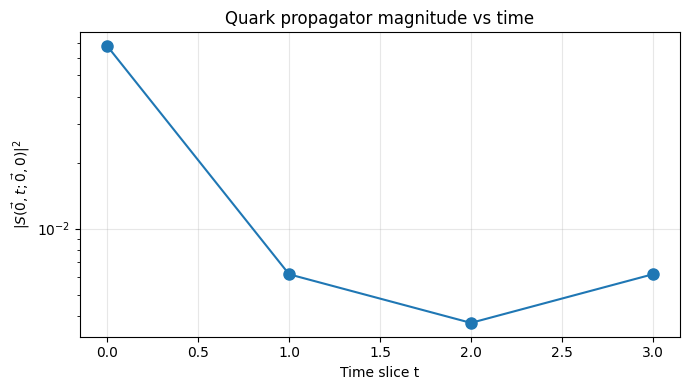

In [5]:
# Sum propagator magnitude over spatial volume at each time slice
Lx, Ly, Lz, Lt = La
prop_vs_t = np.zeros(Lt)

# Use the first pt-pt solution (color=0, spin=0)
prop0 = propagator[0]

for t in range(Lt):
    for x in range(Lx):
        for y in range(Ly):
            for z in range(Lz):
                idx = su2.p2i(np.array([x, y, z, t]), La)
                base = 8 * idx
                # Sum over all color-spin components at this site
                for cs in range(8):
                    prop_vs_t[t] += abs(prop0[base + cs])**2

plt.figure(figsize=(7, 4))
plt.semilogy(range(Lt), prop_vs_t, 'o-', markersize=8)
plt.xlabel('Time slice t')
plt.ylabel(r'$ |S(\vec{0},t; \vec{0}, 0)|^2$')
plt.title('Quark propagator magnitude vs time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Why does the plot look like this?

On a finite lattice with **antiperiodic boundary conditions** on the quarks in time
($\psi(L_t) = -\psi(0)$), the propagator doesn't just decay in one
direction — it also wraps *backward* around the lattice. The squared
magnitude picks up contributions from both directions:
$$ |S(\vec{0},t;\, \vec{0}, 0)|^2 \;\sim\; A\,e^{-2m\,t} \;+\; B\,e^{-2m\,(L_t - t)}$$

This is a **cosh-like** shape. The forward piece dominates near the
source ($t = 0$), the backward piece dominates near $t = L_t$, and the
two meet at the midpoint $t = L_t/2$. That's exactly what we see:

- **$t = 0$**: largest value (source contact point)
- **$t = 1, 2$**: exponential falloff toward the midpoint
- **$t = 2$**: minimum — farthest from the source in *either* time direction
- **$t = 3$**: upturn — backward propagation wrapping around the boundary ($L_t - 3 = 1$, so this point "sees" the source just one step away going backward)

Notice that $t = 1$ and $t = 3$ sit at the same distance from the
nearest boundary and have comparable magnitudes — that's the cosh
symmetry at work.

On our tiny $4^4$ lattice with only 4 time slices, the shape is coarse
but the qualitative physics is all there. On a larger lattice
($L_t = 16$ or $32$) you'd see a smooth exponential decay over many
time slices before the backward-propagating piece kicks in.

### Aside: squaring $|S|^2$ is already mesonic

Notice that the quantity we plotted, $\sum |S(\vec{0}, t; \vec{0}, 0)|^2$,
is already **quark-antiquark**: one factor of $S$ is the quark going
from $0$ to $x$, and the complex-conjugate factor is the antiquark
going the other way. The object $S\,S^\dagger$ is the kernel of a
simple meson correlator. (Compare High Energy Physics Essentials Eq. 10.93,
$C(x,y) = \mathrm{Tr}[|S_u(y-x)|^2]$, obtained from Eq. 10.92,
$\gamma_5 S(x-y)\gamma_5 = S(y-x)^\dagger$.)

This also tells us how a meson transforms under a symmetry that flips
the sign of a single quark: if $\psi \to -\psi$, then $S \to -S$, but
$S \cdot S^\dagger \to (-S)(-S)^\dagger = S\,S^\dagger$. **If both
quarks flip sign, the meson doesn't flip** — a charge/phase on an
individual quark field cancels in the bilinear (this is the same
quadratic-in-$\psi$ structure of the Dirac bilinears in High Energy Physics Essentials
§6.1.7). The same reasoning holds for the full
$\mathrm{Tr}[\Gamma\,S\,\Gamma\,S^\dagger]$ meson
correlators we build in Notebook 09.

## 5. Propagator on a Gauge Background

Now let's solve on a non-trivial (interacting) gauge field.

In [6]:
# Load a sample configuration
config_path = os.path.join(REPO, "configs", "sample_4x4x4x4",
                           "random_4x4x4x4.pkl")
U_rand, meta = load_config(config_path)
print(f"Loaded config, plaquette: {meta.get('plaquette', 'N/A')}")

U_interacting = [None, U_rand]  # format expected by build_wilson_dirac_matrix
D_int = build_wilson_dirac_matrix(mass, La, wilson_r=wilson_r,
                                  U=U_interacting, verbose=True)

# Solve for one source
prop_int = solve_dirac_system(D_int, source, verbose=True)

# Compare norms
print(f"\nFree field propagator norm:     {np.linalg.norm(prop):.4f}")
print(f"Interacting propagator norm: {np.linalg.norm(prop_int):.4f}")

Loaded config, plaquette: 0.5



Free field propagator norm:     0.2898
Interacting propagator norm: 0.2807


## Exercises

1. Compare the propagator magnitude vs time for free-field and interacting cases.
   How does the gauge field affect the decay rate?
2. **Mass dependence**: Change the quark mass to 0.5 and re-solve. Heavier
   quarks decay faster with distance — how does the propagator vs time plot
   change?
3. **Wilson parameter**: Change `wilson_r` from 1.0 to 0.5 and re-solve.
   This shifts the effective mass — verify by comparing the exponential decays of each.
4. **Solver methods**: Try different solver methods (`'direct'`, `'gmres'`)
   and compare the solution norms and residuals. Our code
   (`MesonBase.solve_dirac_system`) uses **LU decomposition** (direct) for
   small lattices ($8V \leq 5000$) and **GMRES** (a Krylov subspace
   iterative method) for larger ones — both from `scipy.sparse.linalg`.
   Which method is used for our $4^4$ lattice?
5. **pt-pt propagator matrix**: Using the code in Section 3, examine the
   $8 \times 8$ pt-pt propagator matrix at the source site ($t=0$, origin).
   Reshape: for each source $(c_s, s_s)$ and sink $(c_k, s_k)$, extract
   `propagator[4*c_s + s_s][8*source_idx + 2*s_k + c_k]`.
   Which components are largest? The matrix should be approximately
   block-diagonal in color — verify this.
6. **Solver comparison**: Time `'direct'` vs `'gmres'` for lattice sizes
   $2^4$ and $4^4$. Use `import time; t0 = time.time()`.
   At what volume does iterative solving become faster than direct?
   Plot solve time vs lattice volume.
7. **Lattice symmetry on $4^4$**: With a point source at the origin on a
   $4^4$ lattice, predict how $|S(\vec{x}, t; \vec{0}, 0)|^2$ behaves under
   $t \leftrightarrow -t$ and $\vec{k} \leftrightarrow -\vec{k}$
   (equivalently $\vec{x} \leftrightarrow -\vec{x}$, mod $L$).
   Which pairs of lattice points must give equal magnitudes, and which
   points should come out larger vs smaller? Sketch the expected
   pattern by hand, then verify by printing `prop_vs_t` at the relevant
   $(t, \vec{x})$ values from your computed `propagator[0]`.